In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

df = pd.read_csv('data/2025_parkinsons.csv')

groups = {
    'Jitter': ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP'],
    'Shimmer': ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA'],
    'Noise': ['NHR', 'HNR'],
    'Nonlinear': ['RPDE', 'D2', 'DFA', 'spread1', 'spread2', 'PPE'],
    'Frequency': ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)'],
}
group_colours = {
    'Jitter': '#E07B7B',
    'Shimmer': '#E0A87B',
    'Noise': '#A8D8A8',
    'Nonlinear': '#7BA8E0',
    'Frequency': '#C9A0DC',
}
ordered_features = [f for g in groups.values() for f in g]
feat_to_group = {f: g for g, feats in groups.items() for f in feats}

corr = df[ordered_features].corr(method='spearman')
print('Spearman correlation matrix computed for', len(ordered_features), 'features.')

Spearman correlation matrix computed for 22 features.


In [2]:
# within group redundancy
print(f"{'Group':12s} {'Mean |r|':>10s}  {'Interpretation'}")
print('-' * 55)
for g, feats in groups.items():
    sub = corr.loc[feats, feats].values
    vals = sub[~np.eye(len(sub), dtype=bool)]
    mean_r = np.abs(vals).mean()
    interpretation = (
        'Extremely redundant' if mean_r > 0.90 else
        'Highly redundant' if mean_r > 0.75 else
        'Moderate overlap' if mean_r > 0.50 else
        'Largely independent features'
    )
    print(f"{g:12s} {mean_r:>8.3f} {interpretation}")

print()
print('Known perfect correlations (by construction):')
print(f" Jitter:DDP = 3 × MDVP:RAP ->  r = {corr.loc['Jitter:DDP','MDVP:RAP']:.4f}")
print(f" Shimmer:DDA = 3 × Shimmer:APQ3 -> r = {corr.loc['Shimmer:DDA','Shimmer:APQ3']:.4f}")

Group          Mean |r|  Interpretation
-------------------------------------------------------
Jitter          0.938 Extremely redundant
Shimmer         0.974 Extremely redundant
Noise           0.866 Highly redundant
Nonlinear       0.429 Largely independent features
Frequency       0.405 Largely independent features

Known perfect correlations (by construction):
 Jitter:DDP = 3 × MDVP:RAP ->  r = 1.0000
 Shimmer:DDA = 3 × Shimmer:APQ3 -> r = 1.0000


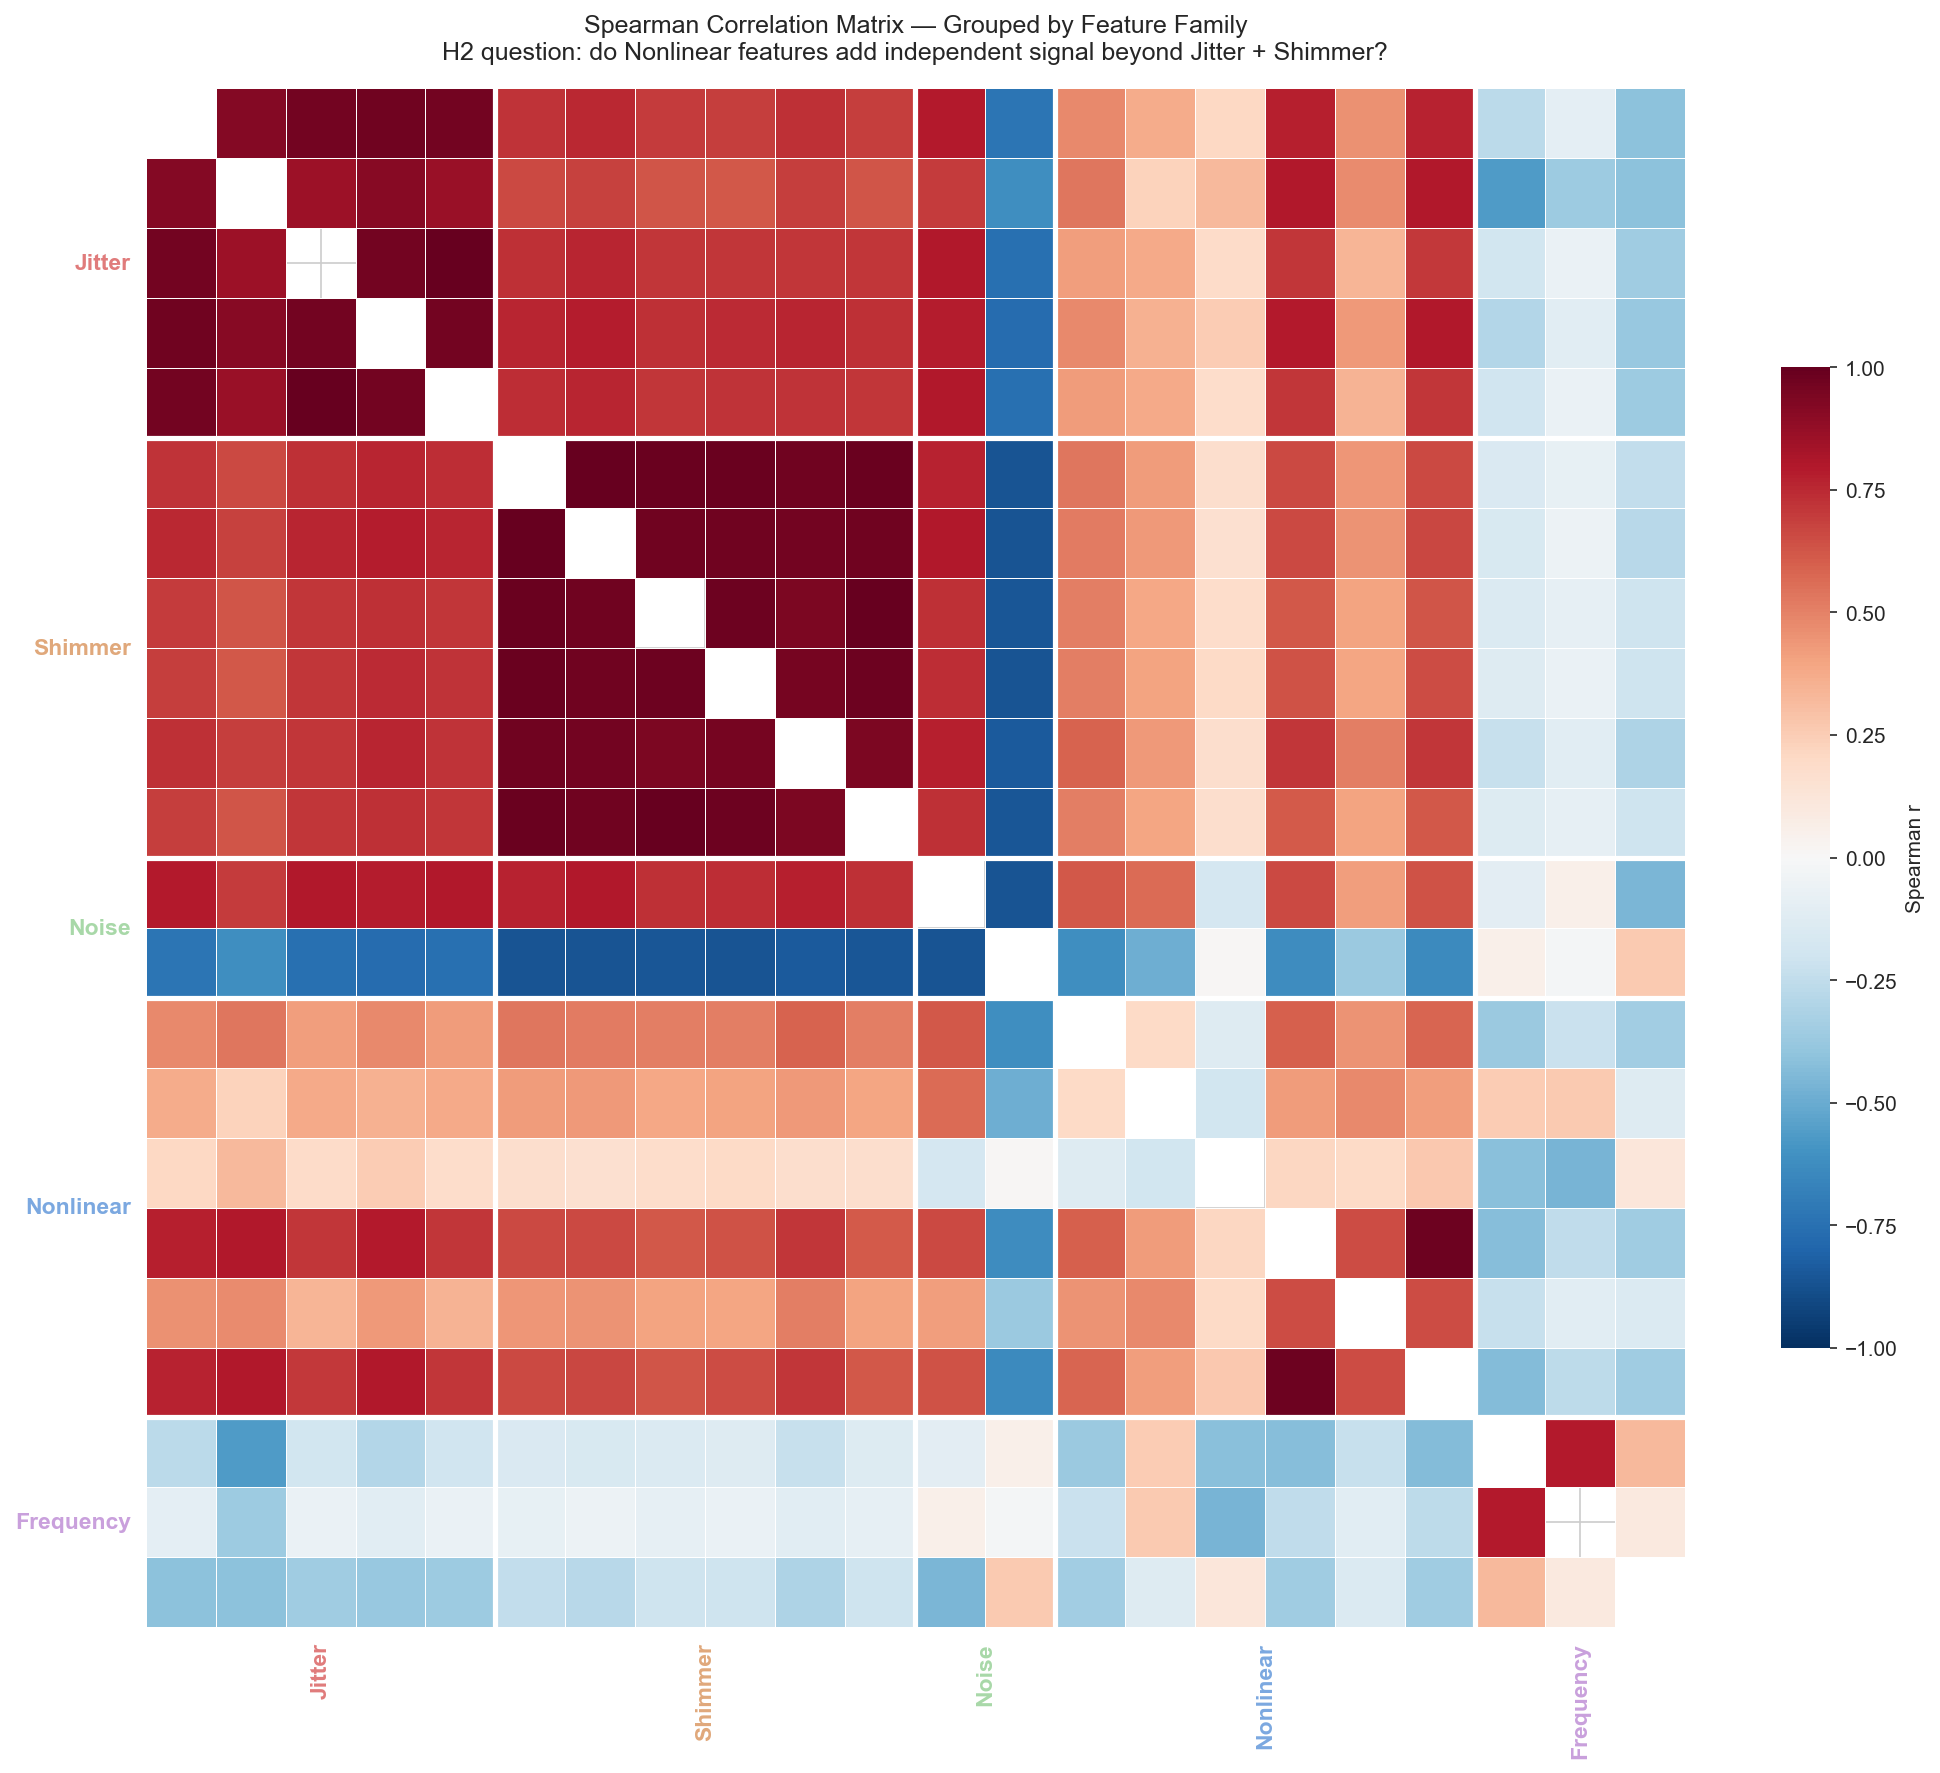

In [3]:
# full group correlation heat map
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(len(ordered_features), dtype=bool)

sns.heatmap(
    corr, ax=ax, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    annot=False, square=True,
    cbar_kws={'label': 'Spearman r', 'shrink': 0.6}
)

boundaries = np.cumsum([0] + [len(v) for v in groups.values()])
for b in boundaries[1:-1]:
    ax.axhline(b, color='white', linewidth=2.5)
    ax.axvline(b, color='white', linewidth=2.5)

tick_positions = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(groups))]
group_names = list(groups.keys())
ax.set_xticks(tick_positions)
ax.set_xticklabels(group_names, fontsize=11, fontweight='bold')
ax.set_yticks(tick_positions)
ax.set_yticklabels(group_names, fontsize=11, fontweight='bold', rotation=0)
for tick, name in zip(ax.get_xticklabels(), group_names):
    tick.set_color(group_colours[name])
for tick, name in zip(ax.get_yticklabels(), group_names):
    tick.set_color(group_colours[name])

ax.set_title(
    'Spearman Correlation Matrix — Grouped by Feature Family\n'
    'H2 question: do Nonlinear features add independent signal beyond Jitter + Shimmer?',
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

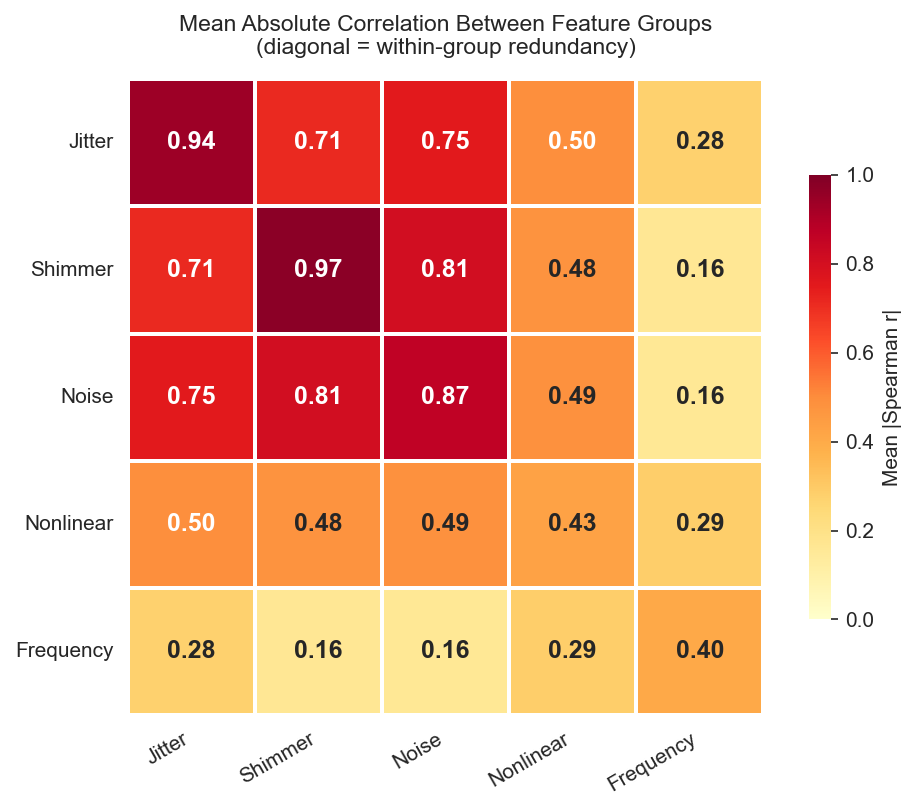

In [4]:
# group level summary heatmap
group_list = list(groups.keys())
n = len(group_list)
cross_corr = np.zeros((n, n))
for i, g1 in enumerate(group_list):
    for j, g2 in enumerate(group_list):
        sub = corr.loc[groups[g1], groups[g2]].values
        vals = sub[~np.eye(len(sub), dtype=bool)] if i == j else sub.flatten()
        cross_corr[i, j] = np.abs(vals).mean()

cross_df = pd.DataFrame(cross_corr, index=group_list, columns=group_list)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cross_df, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=1,
            cbar_kws={'label': 'Mean |Spearman r|', 'shrink': 0.7},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Mean Absolute Correlation Between Feature Groups\n(diagonal = within-group redundancy)', fontsize=11, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('plots/correlation_group_summary.png', dpi=200, bbox_inches='tight')
plt.show()

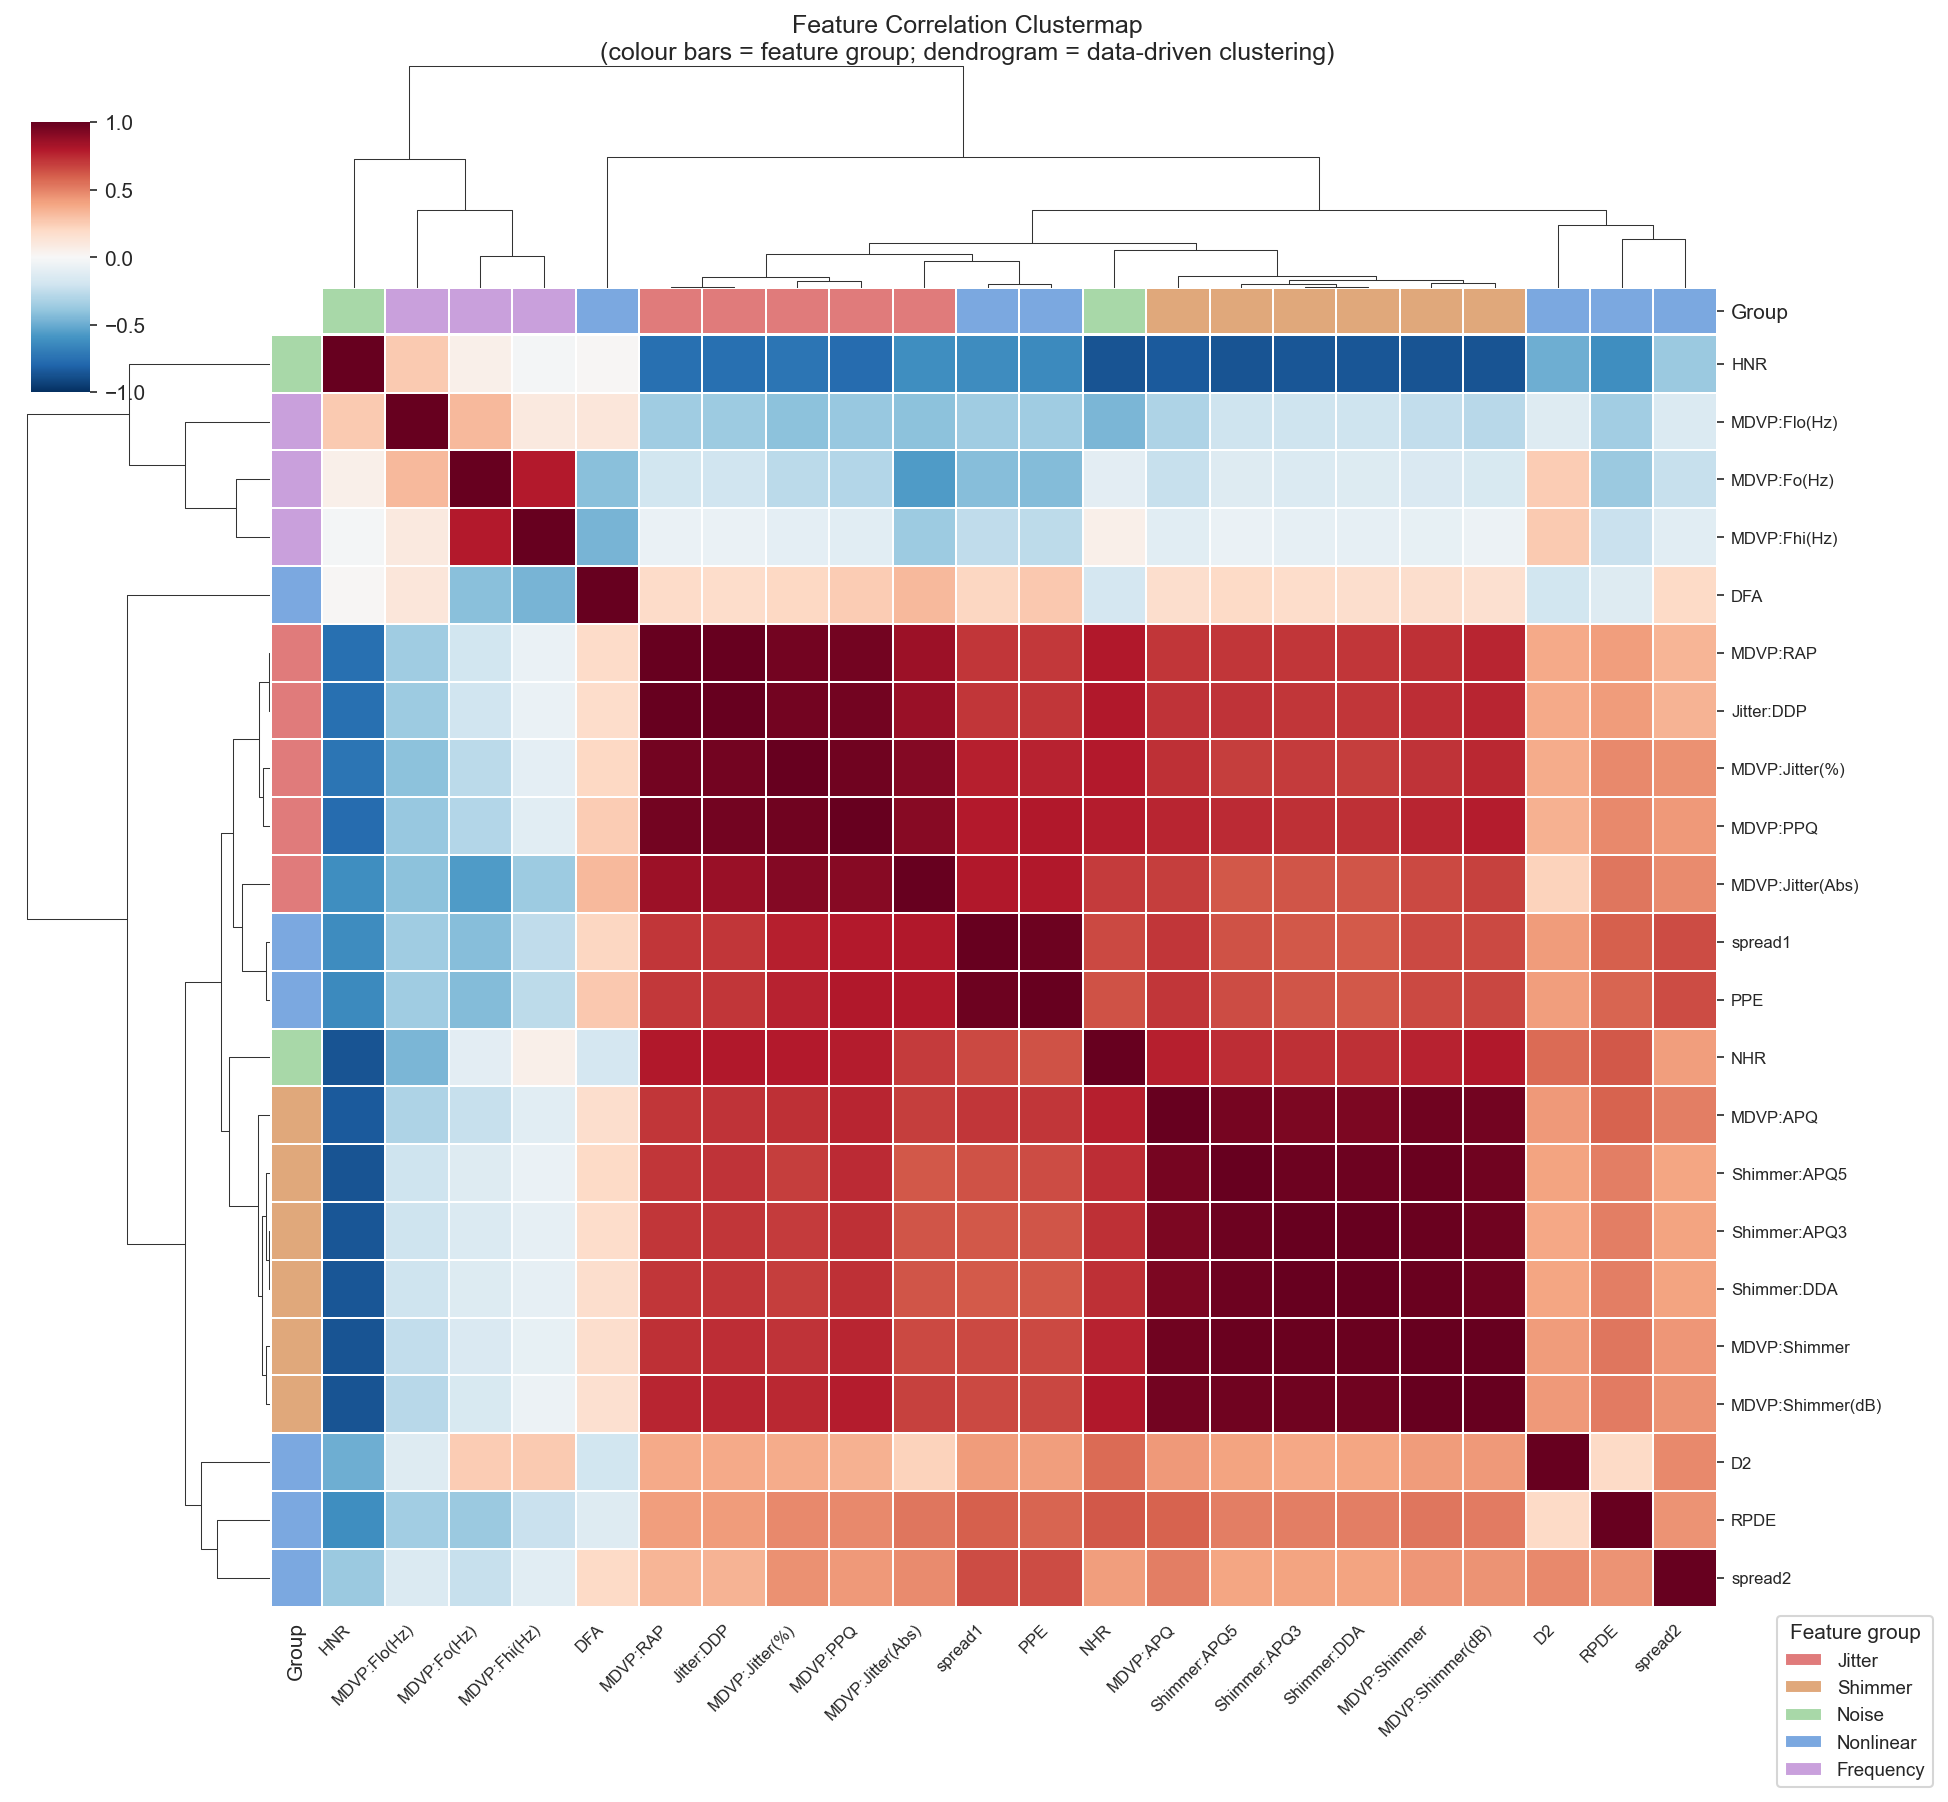

In [5]:
# cluster map (hierarchical clustering of the features based on their correlation)
row_colours = pd.Series(
    {f: group_colours[feat_to_group[f]] for f in ordered_features}, name='Group'
)

g = sns.clustermap(
    corr, method='average', metric='euclidean',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    row_colors=row_colours, col_colors=row_colours,
    linewidths=0.2, figsize=(13, 12),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    xticklabels=True, yticklabels=True
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8, rotation=0)
g.figure.suptitle('Feature Correlation Clustermap\n(colour bars = feature group; dendrogram = data-driven clustering)', fontsize=12, y=1.01)

handles = [mpatches.Patch(facecolor=c, label=gn) for gn, c in group_colours.items()]
g.figure.legend(handles=handles, loc='lower right', bbox_to_anchor=(1.0, 0.02), fontsize=9, title='Feature group')
plt.savefig('plots/correlation_clustermap.png', dpi=180, bbox_inches='tight')
plt.show()

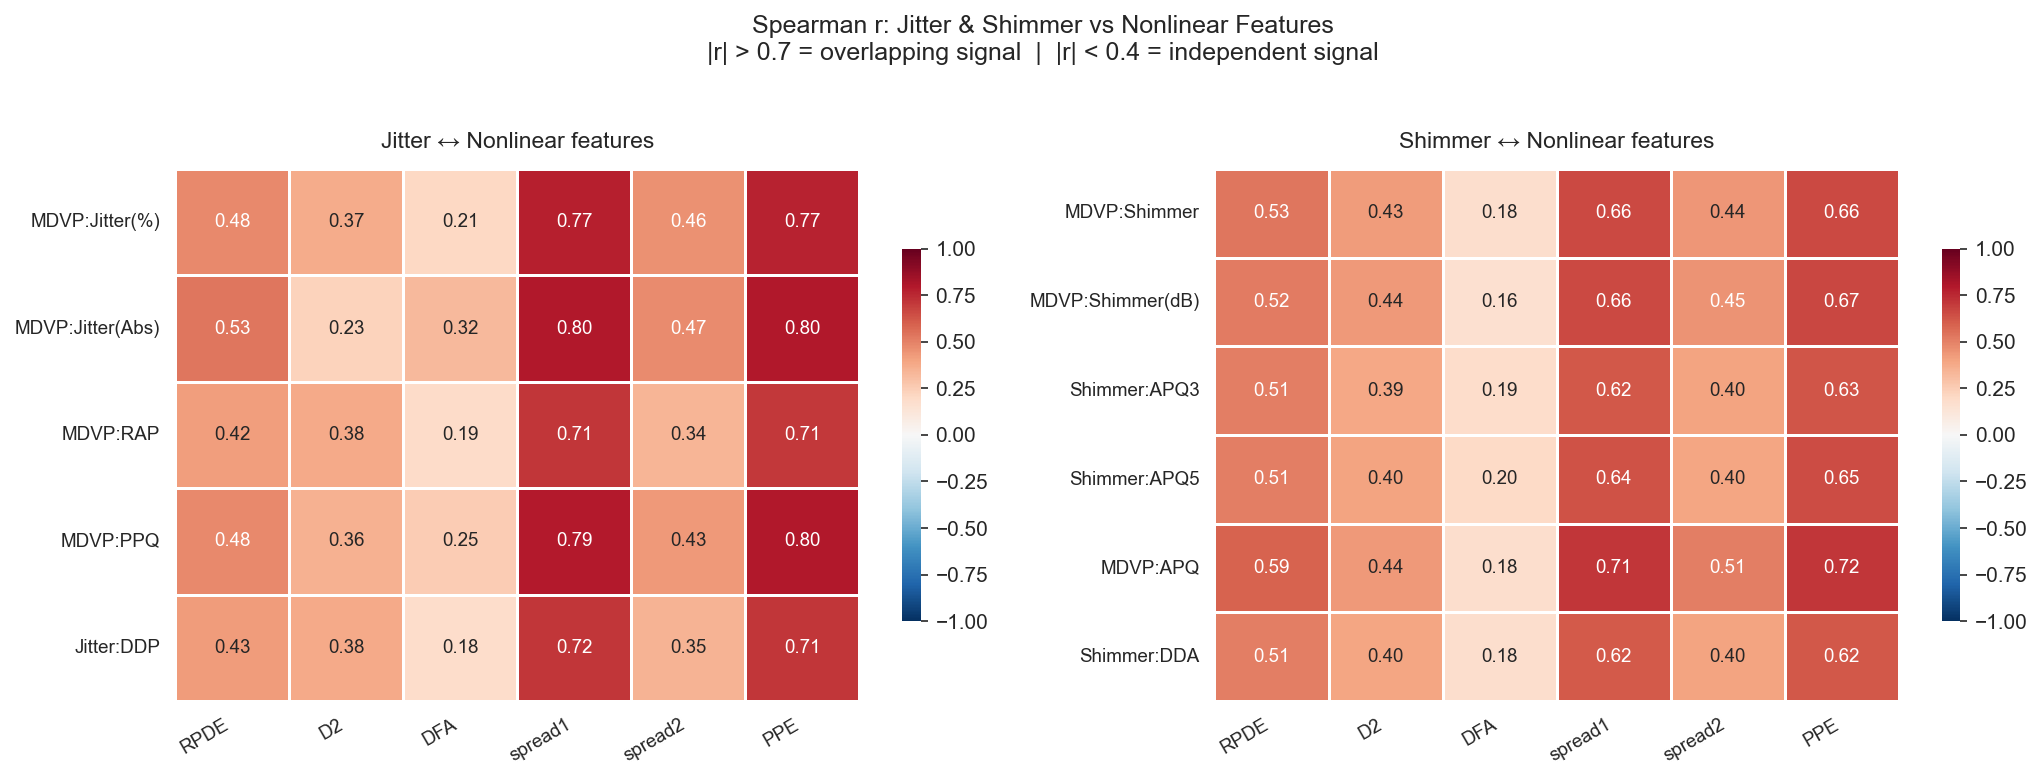

In [6]:
# Spearman correlation between each jitter/shimmer feature and each nonlinear feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp, title in zip(
    axes,
    ['Jitter', 'Shimmer'],
    ['Jitter ↔ Nonlinear features', 'Shimmer ↔ Nonlinear features']
):
    sub = corr.loc[groups[grp], groups['Nonlinear']]
    sns.heatmap(
        sub, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', linewidths=0.5,
        cbar_kws={'shrink': 0.7},
        annot_kws={'size': 9}
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

fig.suptitle('Spearman r: Jitter & Shimmer vs Nonlinear Features\n|r| > 0.7 = overlapping signal  |  |r| < 0.4 = independent signal', 
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('plots/correlation_h2_crossgroup.png', dpi=200, bbox_inches='tight')
plt.show()